# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [1]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Importad aqui el resto de algoritmos a medida que los necesiteis:
# TSNE, AgglomerativeClustering, DBSCAN, GaussianMixture, IsolationForest, metricas...
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [5]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.

df_mushrooms = pd.read_csv("data/mushrooms.csv")

# Display the first five rows of the dataframe
print(df_mushrooms.head())


  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

### Initial observations

The dataset has been loaded successfully and the first five rows confirm that the CSV has been read correctly.

From this initial preview we can already observe:

- The dataset contains **23 columns**, including the target variable `class`.
- All visible features appear to be **categorical**, represented by single-character codes.
- No numerical variables are present, which means the dataset cannot be used directly with distance-based machine learning algorithms.
- The next step is to inspect the dataset in more detail to verify its dimensions, data types and data quality before applying any preprocessing.

**Key takeaway**

A quick inspection of the first rows is an essential first step in any data analysis. It allows us to verify that the dataset has been loaded correctly and provides an initial understanding of its structure before performing more detailed exploration.

### Exploración de datos

### Dataset Overview

#### Objective

Before exploring individual variables, we first examine the overall structure of the dataset.

The goal of this step is to answer a few fundamental questions:

- How many observations are available?
- How many features describe each mushroom?
- What is the overall size of the dataset?

Understanding these characteristics helps us estimate the complexity of the analysis and provides context for the following exploration stages.

In [6]:
# Descripcion del conjunto de datos, estandar.
# Dataset dimensions
rows, columns = df_mushrooms.shape

print(f"Number of observations: {rows}")
print(f"Number of features: {columns}")

# Display dataset dimensions
df_mushrooms.shape

Number of observations: 8124
Number of features: 23


(8124, 23)

### Interpretation

The dataset contains **8,124 mushroom observations**, each described by **23 variables**.

At this point, we know the size of the dataset but not yet the meaning or quality of its features.

The next step is to inspect the data types and verify how the information is stored before making any preprocessing decisions.

### Key Takeaway

One of the first questions a Data Scientist asks is **"How big is my dataset?"**

Knowing the number of observations and variables helps estimate the complexity of the analysis and determines whether additional preprocessing or dimensionality reduction techniques may become necessary later in the workflow.

### Feature Information

#### Objective

After understanding the overall size of the dataset, the next step is to inspect the structure of each feature.

In this section we want to determine:

- the data type of every variable;
- whether any missing values are immediately visible;
- whether the dataset contains numerical or categorical information.

These observations will guide our preprocessing strategy before applying any machine learning algorithms.


In [7]:
# Informacion sobre el tipo de datos de cada feature.

df_mushrooms.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

### Interpretation

The `info()` method provides a high-level overview of the dataset structure.

From this summary we can observe that:

- The dataset contains **8,124 observations** and **23 variables**.
- Every feature is stored as the **string (`str`) data type**, confirming that the dataset is entirely categorical.
- Pandas reports **8,124 non-null values** for every column, meaning that no explicit `NaN` values are present.
- The complete dataset occupies only **1.4 MB of memory**, making it computationally inexpensive to process on a standard computer.

Although the dataset appears complete, this does **not** guarantee that all information is valid. Many categorical datasets represent unknown values using placeholder symbols such as `"?"`, which Pandas treats as ordinary strings rather than missing values.

For this reason, additional data quality checks are still required before any preprocessing or modelling.

### What did I learn?

The `info()` method is one of the first exploratory tools used in Data Science because it provides a quick summary of the dataset without modifying it.

It helps answer questions such as:

- How many observations are available?
- How many variables are included?
- What type of data does each feature contain?
- Are there obvious missing values?
- How much memory does the dataset require?

However, `info()` should **never** be considered a complete data quality assessment. It only detects explicit missing values (`NaN`) and cannot identify hidden missing values encoded as ordinary text.

### Next Decision

Before preparing the data for Machine Learning, the next step is to verify whether the dataset contains **hidden missing values**, such as the `"?"` symbol commonly used in categorical datasets.

This will allow us to determine whether imputation is required before applying encoding or clustering algorithms.

### Objective

Before preprocessing the dataset, we first check for explicit missing values (`NaN`).

Missing values can affect machine learning algorithms and often require imputation or other preprocessing techniques before modelling.

#### Calcular el número de nulos de cada feature

In [8]:
# Igual que otras veces, una linea: contar los nulos por variable.

# Count explicit missing values in each feature
df_mushrooms.isna().sum()


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

### Interpretation

No explicit missing values (`NaN`) were detected in any feature.

At first glance, this suggests that the dataset is complete. However, this conclusion should be treated with caution because categorical datasets often encode unknown values using placeholder symbols instead of actual missing values.

### What did I learn?

The `isna()` method only identifies values stored as `NaN`. It cannot detect hidden missing values represented by strings such as `"?"`, `"Unknown"` or `"N/A"`.

Therefore, checking for explicit missing values is only the first step of a complete data quality assessment.

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

### Objective

In this step, we examine the number of unique values in each feature.

This helps us identify variables with very low variability and detect unusual categories that may require preprocessing before applying machine learning algorithms.

In [11]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...

# Count unique values for each feature
n_values = (
    df_mushrooms.nunique()
    .sort_values()
    .rename("n_unique_values")
    .reset_index()
    .rename(columns={"index": "feature"})
)

n_values

,feature,n_unique_values
0,veil-type,1
1,class,2
2,gill-attachment,2
3,gill-spacing,2
4,stalk-shape,2
5,gill-size,2
6,bruises,2
7,ring-number,3
8,stalk-surface-above-ring,4
9,veil-color,4


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

In [15]:
df_mushrooms["stalk-root"].unique()



<StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str

In [16]:
df_mushrooms["veil-type"].unique()

<StringArray>
['p']
Length: 1, dtype: str

### Interpretation

By inspecting the unique values of the relevant features, we identified two important findings:

- **`veil-type`** contains only one category (`'p'`) across all observations. Since this feature never changes, it cannot help distinguish between different mushrooms and is unlikely to contribute useful information to machine learning models.
- **`stalk-root`** contains the value `"?"`, which according to the dataset documentation represents an **unknown value** rather than a valid category. This means the dataset includes hidden missing values that must be handled during preprocessing.

### What did I learn?

Exploring the unique values of each feature helps detect data quality issues that are not visible with `isna()` alone.

In this case, we identified:
- a **constant feature**, which provides no discriminatory information;
- a **hidden missing value**, which must be treated appropriately before modelling.

### Objective

We identified that the `"?"` symbol represents an unknown value rather than a valid category.

In this step, we replace these hidden missing values with the most frequent category (mode), allowing the dataset to be used by machine learning algorithms without losing observations.

#### Tratar aquellos valores que entendamos que sean nulos

In [18]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.

# Replace the hidden missing value with NaN
df_mushrooms["stalk-root"] = df_mushrooms["stalk-root"].replace("?", np.nan)

# Impute missing values using the most frequent category (mode)
mode_value = df_mushrooms["stalk-root"].mode()[0]

df_mushrooms["stalk-root"] = df_mushrooms["stalk-root"].fillna(mode_value)

# Verify the result
print(f"Mode used for imputation: {mode_value}")
print("\nUnique values after imputation:")
print(df_mushrooms["stalk-root"].unique())

Mode used for imputation: b

Unique values after imputation:
<StringArray>
['e', 'c', 'b', 'r']
Length: 4, dtype: str


### Interpretation

The hidden missing values (`"?"`) were successfully replaced using the mode of the `stalk-root` feature, which was **`b`**.

After imputation, the `"?"` category no longer appears among the unique values, confirming that the preprocessing step was successful.

### What did I learn?

Missing values should be handled before training machine learning models.

For categorical variables, imputing with the **mode** is a simple and commonly used strategy because it preserves all observations without introducing invalid categories.

### Objective

Before training a machine learning model, we check whether every feature provides useful information.

Features with only one unique value contain no variability and cannot help distinguish between observations. Removing them simplifies the dataset without losing information.

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [19]:
# Dejar por el camino las features con un solo valor (no aportan nada).

# Identify constant features
constant_features = df_mushrooms.columns[df_mushrooms.nunique() == 1]

print("Constant features:")
print(constant_features.tolist())

# Remove constant features
df_mushrooms = df_mushrooms.drop(columns=constant_features)

print(f"\nDataset shape after removing constant features: {df_mushrooms.shape}")

Constant features:
['veil-type']

Dataset shape after removing constant features: (8124, 22)


### Interpretation

The analysis identified **`veil-type`** as the only constant feature in the dataset.

Since this variable always contains the same value (`'p'`), it cannot help distinguish between different mushrooms. Removing it simplifies the dataset without losing any useful information.

After removing this feature, the dataset contains **8,124 observations** and **22 variables**.

### What did I learn?

Features that never change have **zero variability** and do not contribute to machine learning models.

Removing constant features is a common preprocessing step because it reduces unnecessary information while preserving the dataset's predictive value.

#### Separar entre variables predictoras y variable a predecir

### Objective

The target variable (`class`) is separated from the predictor variables before preprocessing.

Although clustering algorithms will not use this label, we keep it to evaluate later how well the unsupervised methods recover the natural structure of the dataset.

In [20]:
# La variable a predecir es 'class'.
# y =
# X =

# Target variable
y = df_mushrooms["class"]

# Predictor variables
X = df_mushrooms.drop(columns="class")

print(f"Predictor variables: {X.shape[1]}")
print(f"Target variable: {y.name}")

Predictor variables: 21
Target variable: class


### Interpretation

The dataset has been successfully divided into:

- **X**, containing the predictor variables used for machine learning.
- **y**, containing the reference labels (`class`).

The target variable is not part of the feature matrix and will be reserved for evaluation purposes only.

### What did I learn?

In supervised learning, the target variable is used during training.

In this workshop, however, the clustering algorithms will **not** use `class`. We keep it only to compare the discovered clusters with the true mushroom labels after the analysis is complete.

#### Codificar correctamente las variables categóricas a numéricas

### Objective

Machine learning algorithms cannot work directly with categorical text values.

In this step, we apply **One-Hot Encoding** to transform each category into a numerical representation while preserving its original meaning.

In [21]:
# One Hot Encoder (una linea). Pista: pd.get_dummies

# Apply One-Hot Encoding to all categorical features
X = pd.get_dummies(X)

print(f"Encoded dataset shape: {X.shape}")

X.head()

Encoded dataset shape: (8124, 115)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


### Interpretation

The categorical features have been successfully transformed into **115 numerical features** using One-Hot Encoding.

Each original category is now represented as a binary variable (`0` or `1`), allowing machine learning algorithms to process the dataset without introducing artificial ordering between categories.

### What did I learn?

One-Hot Encoding converts categorical variables into a numerical format while preserving their meaning.

Although the number of features increases (from **21** to **115**), this transformation is necessary because most machine learning algorithms cannot work directly with text values.

#### Train / test split

In [22]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

### Objective

The dataset now contains **115 numerical features**, making it impossible to visualize directly.

Principal Component Analysis (PCA) reduces the dimensionality of the data by creating new variables, called **principal components**, that retain as much information (variance) as possible.

This allows us to visualize the dataset in two dimensions while preserving its overall structure.

In [23]:
# pca =       # metodo de sklearn
# pca.fit(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento

# Fit PCA using two principal components
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train)

print(f"Original dimensions: {X_train.shape[1]}")
print(f"Reduced dimensions: {X_train_pca.shape[1]}")


Original dimensions: 115
Reduced dimensions: 2


Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

### Objective

Before applying clustering algorithms, we train a **Random Forest classifier** as a supervised baseline.

The goal is not to compare supervised and unsupervised learning, but to estimate how much predictive information is contained in the dataset.

This baseline will help us understand whether the clusters discovered later are likely to reflect the true structure of the data.

In [24]:
# 1. Definir el clasificador y el numero de estimadores
# 2. Entrenar en train
# 3. Calcular la precision sobre test

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train a Random Forest classifier as a supervised baseline
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

# Evaluate on the test set
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Random Forest accuracy: {accuracy:.4f}")

Baseline Random Forest accuracy: 1.0000


### Interpretation

The Random Forest classifier achieved an **accuracy of 100%** on the test set.

This indicates that the predictor variables contain a very strong signal for distinguishing between edible and poisonous mushrooms.

### What did I learn?

The supervised baseline confirms that the dataset is highly informative.

This does **not** mean that clustering algorithms will achieve the same performance, since they will not use the target labels during training.

Instead, this result provides a reference point for evaluating how well unsupervised methods recover the underlying structure of the data.

Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [25]:
X_train.shape

(5443, 115)

### Interpretation

The training dataset contains **5,443 observations** described by **115 numerical features**.

Although the dataset is not particularly large in terms of observations, the number of features is relatively high due to the One-Hot Encoding process.

### What did I learn?

Working with many features can increase computational complexity and make visualization impossible.

Dimensionality reduction techniques such as **PCA** help summarize the information into a smaller number of components while preserving as much variance as possible.

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

### Objective

PCA can reduce the number of features while preserving most of the information in the dataset.

In this experiment, we evaluate how the number of principal components affects the performance of a Random Forest classifier. The goal is to identify the smallest number of components that maintains a high predictive accuracy.

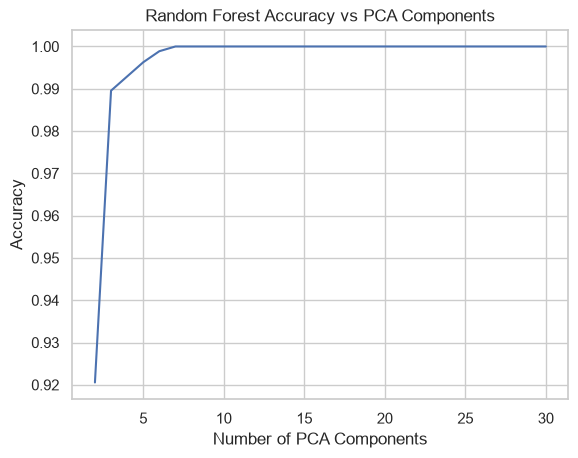

In [27]:
# n_features = # definir un rango de valores a probar
# scores = []

# for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    # 2. Entrenar Random Forest sobre los datos reducidos
    # 3. Guardar el score en test

# sns.lineplot(x=list(n_features), y=scores)


# Number of PCA components to evaluate
n_features = range(2, 31)

scores = []

for n in n_features:

    # Apply PCA
    pca = PCA(n_components=n, random_state=RANDOM_STATE)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    )

    rf.fit(X_train_pca, y_train)

    # Evaluate
    y_pred = rf.predict(X_test_pca)

    scores.append(accuracy_score(y_test, y_pred))

# Plot results
sns.lineplot(x=list(n_features), y=scores)

plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs PCA Components")

plt.show()

### Interpretation

The classifier quickly reaches a very high accuracy as the number of principal components increases.

Around **10 principal components**, the Random Forest already achieves nearly the same performance as when using all **115 encoded features**.

### What did I learn?

Using more features does not always improve a machine learning model.

PCA can compress the information contained in many variables into a much smaller number of components while preserving most of the predictive power.

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

### Objective

PCA provides a linear projection of the data, but some complex structures may remain hidden.

t-SNE is a non-linear dimensionality reduction technique designed to preserve the local neighbourhood of the observations, making clusters easier to visualize.

Because t-SNE is computationally expensive, we apply it to a sample of the training data.

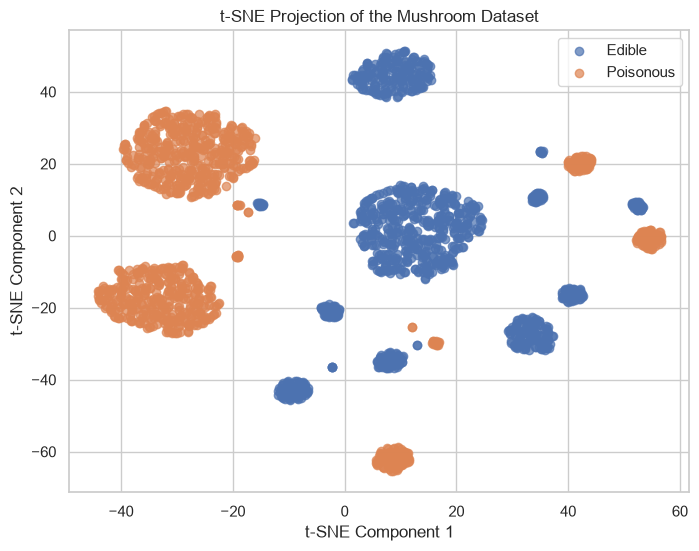

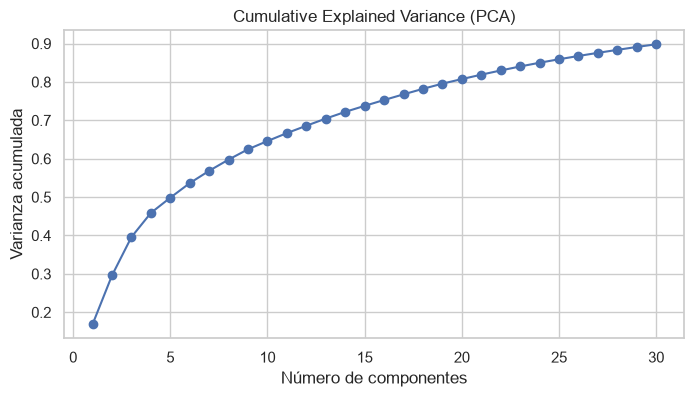

In [30]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
# 2. Definir TSNE(n_components=2, ...) y ajustar
# 3. Pintar el embedding coloreado por la etiqueta

from sklearn.manifold import TSNE

# Take a random sample from the training set
sample_size = 2000

X_sample = X_train.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

y_sample = y_train.loc[X_sample.index]

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_sample)

# Plot
plt.figure(figsize=(8,6))

for label, color in zip(["Edible", "Poisonous"], ["#F4E6D8", "#0D0D1A"]):
    idx = y_sample == ("e" if label == "Edible" else "p")
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection of the Mushroom Dataset")
plt.legend()

plt.show()

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,4))
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker="o"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Cumulative Explained Variance (PCA)")
plt.grid(True)

plt.show()

### Conclusions

The dimensionality reduction analysis reveals that the Mushroom dataset contains a strong underlying structure.

PCA reduced the encoded dataset from **115 features to 2 principal components**, allowing an initial visualization of the observations. The supervised experiment also showed that approximately **10 PCA components** are sufficient to retain almost all the predictive performance achieved with the complete feature set.

The t-SNE projection produced several compact groups, with edible and poisonous mushrooms occupying mostly different regions. This suggests that the original categorical features contain patterns that may be recoverable through unsupervised learning.

### Key Takeaways

- PCA summarizes high-dimensional data by preserving as much global variance as possible.
- A much smaller number of components can retain most of the useful information.
- t-SNE preserves local neighbourhoods and is mainly used for exploratory visualization.
- The visible separation is promising, but it does not prove that the clusters are objectively correct.
- The next step is to apply clustering algorithms and validate whether they recover meaningful groups without using `class` during training.

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

## Objective

Until now, we have explored and prepared the dataset, reduced its dimensionality, and confirmed that it contains a strong predictive signal.

In this section, we move to **unsupervised learning**. The clustering algorithms will only receive the predictor variables and will attempt to group similar mushrooms **without using the target variable (`class`)**.

The resulting clusters will later be compared with the true labels to evaluate how well each algorithm recovered the natural structure of the dataset.

In [31]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red


# Reduce the encoded dataset to 10 principal components

pca = PCA(
    n_components=10,
    random_state=RANDOM_STATE
)

X_red = pca.fit_transform(X)

print(f"Original dimensions: {X.shape[1]}")
print(f"Reduced dimensions: {X_red.shape[1]}")

Original dimensions: 115
Reduced dimensions: 10


### Interpretation

The clustering algorithms will operate on the PCA representation instead of the full One-Hot encoded dataset.

Reducing the dimensionality removes redundancy, decreases computational cost and often improves clustering performance by reducing noise.

### What did I learn?

PCA is not only useful for visualization.

It can also be used as a preprocessing step before clustering, allowing the algorithms to work with a more compact representation of the original data.

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

### Objective

K-Means requires us to define the number of clusters (`k`) before training.

Since we do not know the optimal value in advance, we evaluate several values of `k` using two complementary metrics:

- **Elbow Method**, based on inertia (within-cluster sum of squared distances).
- **Silhouette Score**, which measures how well separated the clusters are.

The goal is to choose a value of `k` that balances compact clusters with good separation.

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []
silhouettes = []

for k in k_values:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = km.fit_predict(X_red)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, labels))

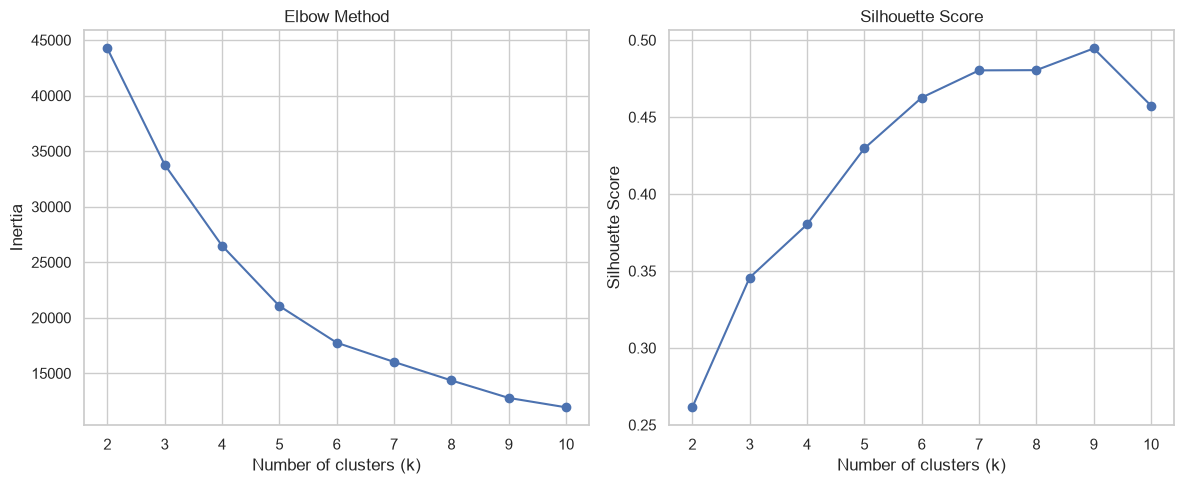

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Elbow
ax[0].plot(k_values, inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")

# Silhouette
ax[1].plot(k_values, silhouettes, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

### Interpretation

The Elbow Method evaluates how the within-cluster variability decreases as more clusters are added.

The Silhouette Score evaluates the quality of the clustering by measuring how similar each sample is to its own cluster compared with neighbouring clusters.

The optimal value of `k` is usually located near the elbow while also producing a high silhouette score.

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

### Objective

After selecting the number of clusters, we train the final K-Means model using the reduced PCA representation.

Although K-Means is trained without the target labels, we can compare the discovered clusters with the true mushroom classes to evaluate how much of the underlying structure has been recovered.

For this purpose, we use:

- Cluster visualization.
- Adjusted Rand Index (ARI).
- Normalized Mutual Information (NMI).

Adjusted Rand Index (ARI): 0.6171
Normalized Mutual Information (NMI): 0.5663


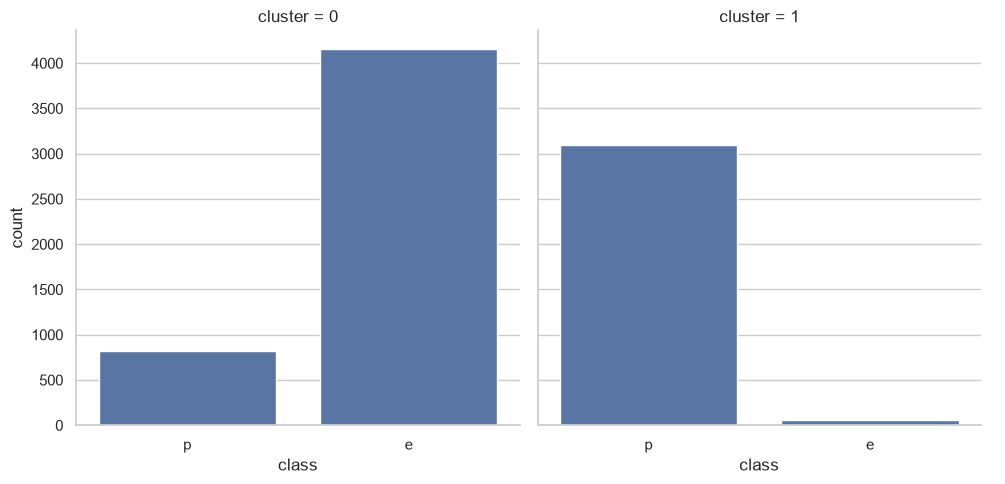

In [38]:
# Train K-Means using the selected value of k
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_red)

# Prepare a DataFrame for visualization

comparison = pd.DataFrame({
    "cluster": cluster_labels,
    "class": y
})

# Compare the real class distribution inside each cluster

ax = sns.catplot(
    data=comparison,
    x="class",
    col="cluster",
    kind="count",
    col_wrap=2
)

# Calculate ARI and NMI

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Interpretation

K-Means successfully identified two groups that largely correspond to the edible and poisonous mushroom classes.

Although the algorithm never used the target labels during training, the resulting clusters show a clear association with the real classes.

The obtained ARI (0.617) and NMI (0.566) indicate that the discovered clustering captures a substantial part of the underlying structure, although some observations remain grouped differently.

### What did I learn?

This experiment demonstrates one of the main ideas behind unsupervised learning.

Even without knowing the correct answers, clustering algorithms can recover meaningful patterns when the dataset contains a strong natural structure. However, unlike supervised models, perfect agreement with the true labels is not expected.

### Design Decision

The comparison between clustering algorithms will be completed **after all models have been trained and evaluated**.

Although it is possible to define the evaluation function in advance, postponing the comparison improves the readability of the notebook and follows the natural workflow of a Machine Learning project:

1. Train each algorithm individually.
2. Understand its behaviour and assumptions.
3. Evaluate its performance.
4. Compare all algorithms using the same metrics.

This approach keeps the notebook organised and makes the final comparison easier to interpret, since every model has already been analysed independently.

### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

### Objective

Agglomerative Clustering builds a hierarchy by progressively merging similar observations.

A dendrogram allows us to visualize this process. The height at which two branches merge represents how different those groups are.

Because hierarchical clustering is computationally expensive and a full dendrogram would be difficult to read, we use a reproducible sample of the PCA representation.

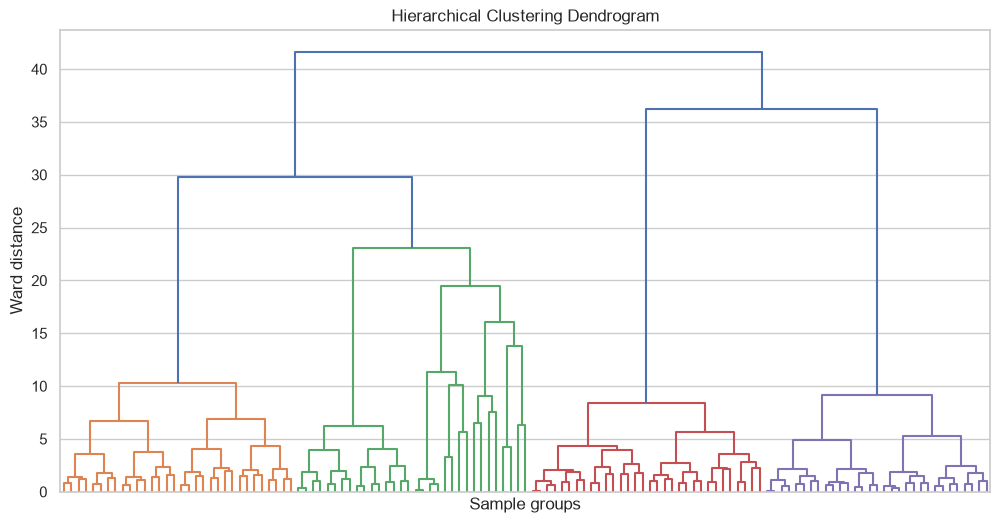

In [40]:
# 1. Tomar una muestra de X_red
# 2. linkage(..., method='ward')
# 3. dendrogram(...) para visualizar la jerarquia


from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Take a reproducible sample from the PCA representation
rng = np.random.default_rng(RANDOM_STATE)
sample_indices = rng.choice(
    X_red.shape[0],
    size=500,
    replace=False
)

X_red_sample = X_red[sample_indices]

# Compute the hierarchical linkage matrix
linkage_matrix = linkage(
    X_red_sample,
    method="ward"
)

# Plot the dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=6,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample groups")
plt.ylabel("Ward distance")
plt.show()

### Interpretation

The dendrogram shows how observations are progressively merged into larger groups.

Large vertical distances between successive merges suggest possible divisions in the data. The visualization supports the existence of a hierarchical structure, although the exact number of clusters should also be evaluated using quantitative metrics.

### What did I learn?

Hierarchical clustering does not require an initial set of centroids. It builds a nested structure of groups, and the dendrogram helps visualize how similar or different those groups are.

### 2. Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

### Agglomerative Clustering

Agglomerative Clustering starts with each observation as an individual cluster and progressively merges the closest groups.

We use two clusters to compare its result with the known binary reference label. The label is used only after training for validation.

In [41]:
# Train Agglomerative Clustering
agglomerative = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agglomerative_labels = agglomerative.fit_predict(X_red)

# Evaluate against the reference label
agglomerative_ari = adjusted_rand_score(
    y,
    agglomerative_labels
)

agglomerative_nmi = normalized_mutual_info_score(
    y,
    agglomerative_labels
)

print(
    f"Agglomerative ARI: "
    f"{agglomerative_ari:.4f}"
)
print(
    f"Agglomerative NMI: "
    f"{agglomerative_nmi:.4f}"
)

Agglomerative ARI: 0.6090
Agglomerative NMI: 0.5936


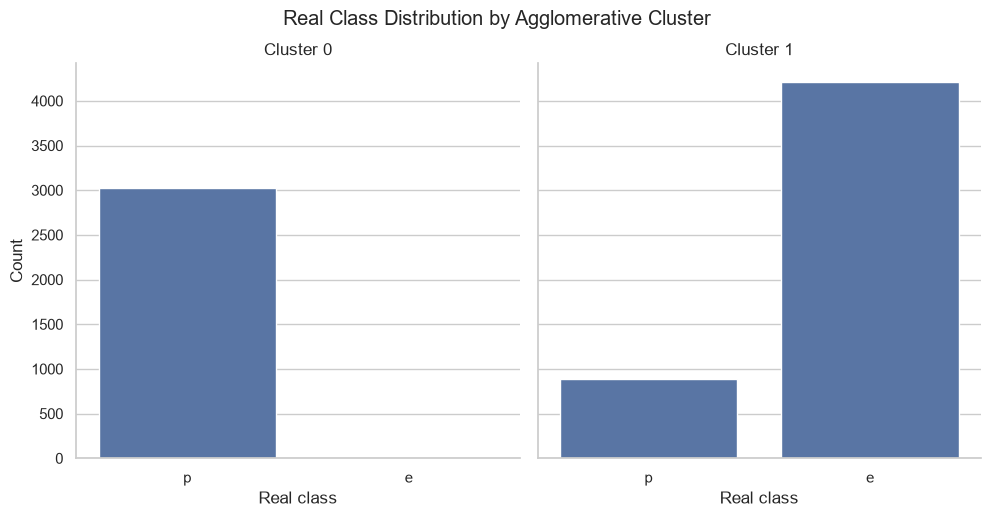

In [42]:
agglomerative_comparison = pd.DataFrame({
    "cluster": agglomerative_labels,
    "class": y
})

ax = sns.catplot(
    data=agglomerative_comparison,
    x="class",
    col="cluster",
    kind="count",
    col_wrap=2
)

ax.set_axis_labels("Real class", "Count")
ax.set_titles("Cluster {col_name}")
ax.figure.suptitle(
    "Real Class Distribution by Agglomerative Cluster",
    y=1.03
)

plt.show()

### Interpretation

Agglomerative Clustering identified two groups without using the `class` variable during training.

The class distribution inside each cluster and the ARI and NMI scores show how closely the hierarchical groups correspond to the edible and poisonous reference classes.

### What did I learn?

Different clustering algorithms may recover different structures from the same dataset because they use different assumptions.

K-Means searches for compact groups around centroids, while Agglomerative Clustering builds a hierarchy by merging similar observations.

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [44]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest


# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

# DBSCAN with Euclidean distance on the PCA representation
dbscan_euclidean = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric="euclidean"
)

labels_dbscan_euclidean = dbscan_euclidean.fit_predict(X_red)

ari_dbscan_euclidean = adjusted_rand_score(
    y,
    labels_dbscan_euclidean
)

# DBSCAN with Jaccard distance on the binary One-Hot representation
X_binary = X.astype(bool)

dbscan_jaccard = DBSCAN(
    eps=0.35,
    min_samples=5,
    metric="jaccard"
)

labels_dbscan_jaccard = dbscan_jaccard.fit_predict(X_binary)

ari_dbscan_jaccard = adjusted_rand_score(
    y,
    labels_dbscan_jaccard
)

print(f"Euclidean DBSCAN ARI: {ari_dbscan_euclidean:.4f}")
print(f"Jaccard DBSCAN ARI: {ari_dbscan_jaccard:.4f}")

print(
    "\nEuclidean clusters:",
    np.unique(labels_dbscan_euclidean, return_counts=True)
)

print(
    "\nJaccard clusters:",
    np.unique(labels_dbscan_jaccard, return_counts=True)
)

Euclidean DBSCAN ARI: 0.3736
Jaccard DBSCAN ARI: 0.3236

Euclidean clusters: (array([0, 1, 2, 3, 4, 5]), array([3852,  768, 1296,  288, 1728,  192]))

Jaccard clusters: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([3944,  768, 1296, 1728,   48,   80,    8,  192,   36,    8,   16]))


### Interpretation

DBSCAN produced very different results depending on the distance metric.

Euclidean distance was applied to the PCA representation, while Jaccard distance was applied to the binary One-Hot encoded data. Comparing their ARI scores shows which representation and distance measure better recover the known class structure.

### What did I learn?

The same clustering algorithm can behave very differently when the distance metric changes.

For categorical data represented as binary variables, Jaccard distance is often more appropriate because it measures shared active categories rather than geometric distance.

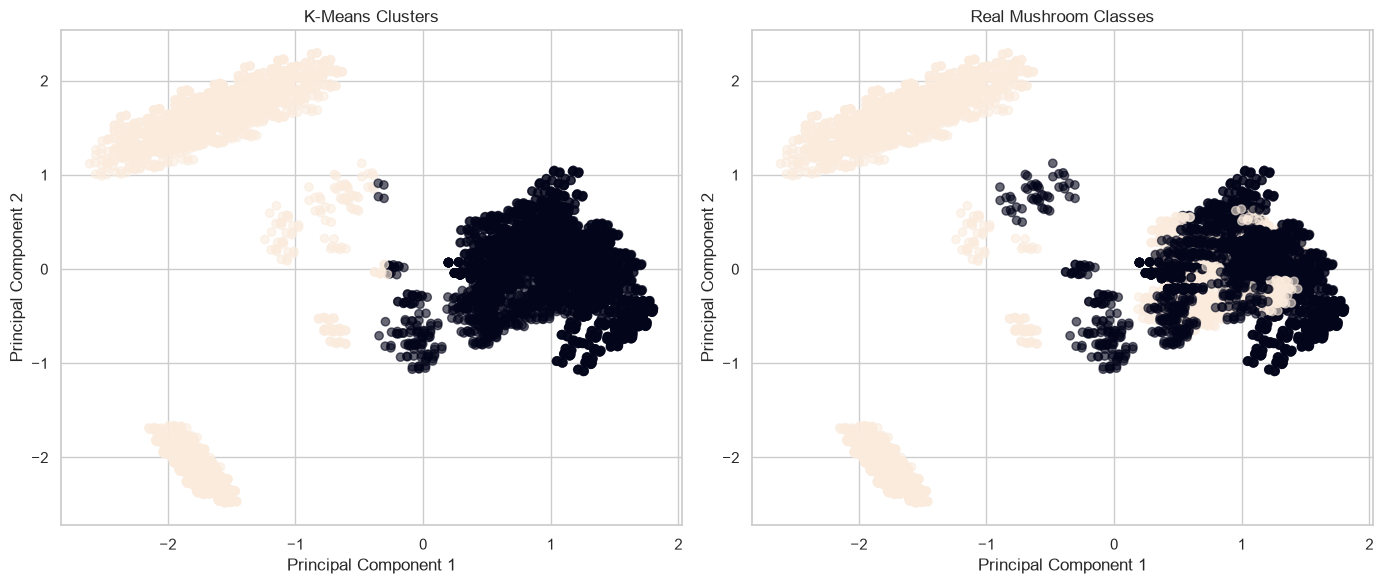

In [45]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

pca_visual = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_visual = pca_visual.fit_transform(X)

y_binary = (y == "p").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=cluster_labels,
    alpha=0.6
)

axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=y_binary,
    alpha=0.6
)

axes[1].set_title("Real Mushroom Classes")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

### Interpretation

DBSCAN produced very different results depending on the distance metric.

Euclidean distance was applied to the PCA representation, while Jaccard distance was applied to the binary One-Hot encoded data. Comparing their ARI scores shows which representation and distance measure better recover the known class structure.

### What did I learn?

The same clustering algorithm can behave very differently when the distance metric changes.

For categorical data represented as binary variables, Jaccard distance is often more appropriate because it measures shared active categories rather than geometric distance.

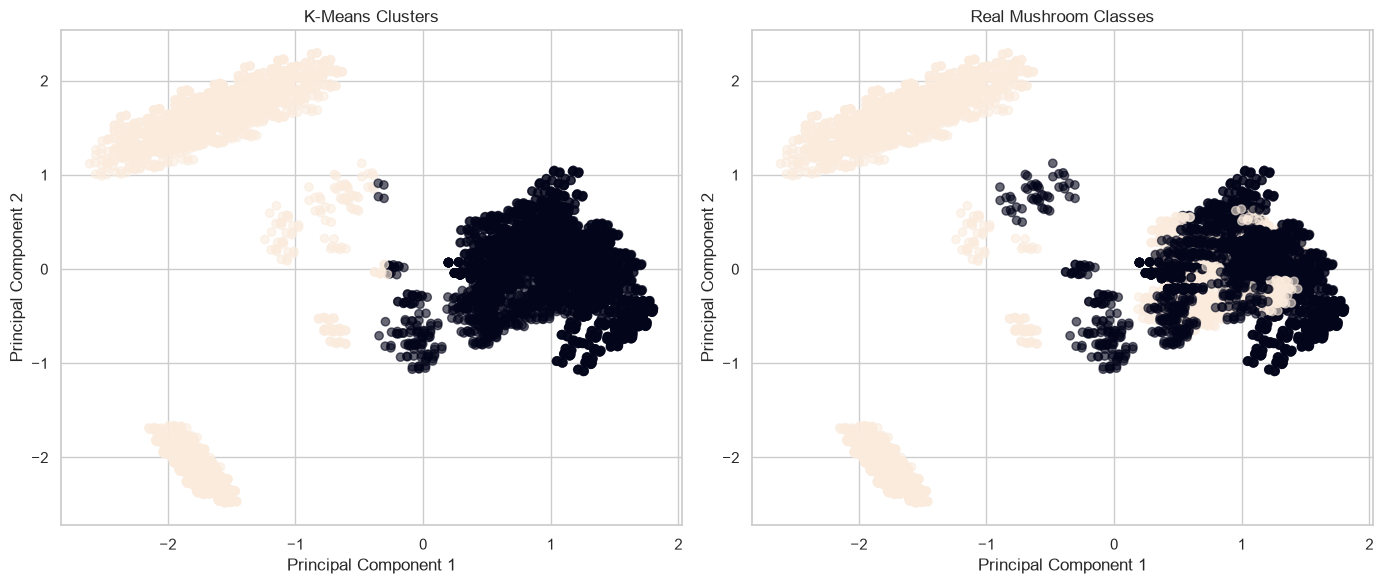

In [47]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

pca_visual = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_visual = pca_visual.fit_transform(X)

y_binary = (y == "p").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=cluster_labels,
    alpha=0.6
)

axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=y_binary,
    alpha=0.6
)

axes[1].set_title("Real Mushroom Classes")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

### Interpretation

The two PCA projections show a visible similarity between the K-Means clusters and the real mushroom classes.

The agreement is not perfect, but the comparison confirms that K-Means recovered a substantial part of the edible/poisonous structure without using the target labels during training.

### What did I learn?

Visual comparison helps us understand clustering results, but it should be interpreted together with quantitative metrics such as ARI and NMI.

Detected anomalies: 1491
Anomaly proportion: 18.35%


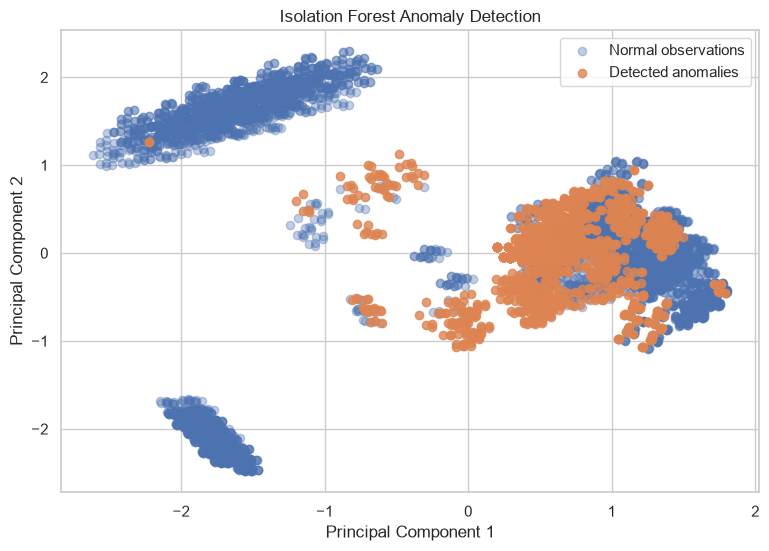

In [48]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# 2. predict -> -1 son anomalias
# 3. Pintarlas sobre la proyeccion PCA

isolation_forest = IsolationForest(
    contamination="auto",
    random_state=RANDOM_STATE
)

anomaly_labels = isolation_forest.fit_predict(X_red)

anomaly_mask = anomaly_labels == -1
n_anomalies = anomaly_mask.sum()

print(f"Detected anomalies: {n_anomalies}")
print(f"Anomaly proportion: {n_anomalies / len(X_red):.2%}")

plt.figure(figsize=(9, 6))

plt.scatter(
    X_visual[~anomaly_mask, 0],
    X_visual[~anomaly_mask, 1],
    alpha=0.35,
    label="Normal observations"
)

plt.scatter(
    X_visual[anomaly_mask, 0],
    X_visual[anomaly_mask, 1],
    alpha=0.8,
    label="Detected anomalies"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()

### Interpretation

Isolation Forest identified observations that are easier to isolate from the rest of the dataset.

These points are statistically unusual according to the model, but they are not automatically errors. They may represent rare combinations of mushroom characteristics.

### What did I learn?

Clustering searches for groups of similar observations, while anomaly detection searches for observations that differ substantially from the majority.

> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

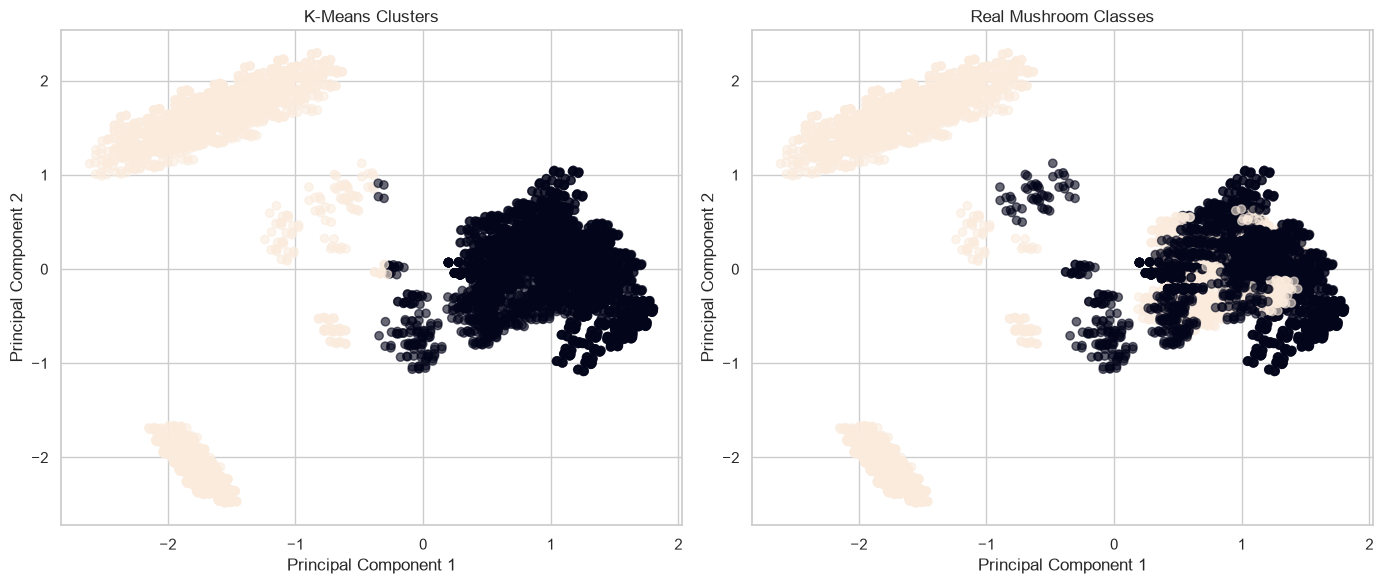

In [49]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

pca_visual = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_visual = pca_visual.fit_transform(X)

y_binary = (y == "p").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=cluster_labels,
    alpha=0.6
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=y_binary,
    alpha=0.6
)
axes[1].set_title("Real Mushroom Classes")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()



Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

Detected anomalies: 1491
Anomaly proportion: 18.35%


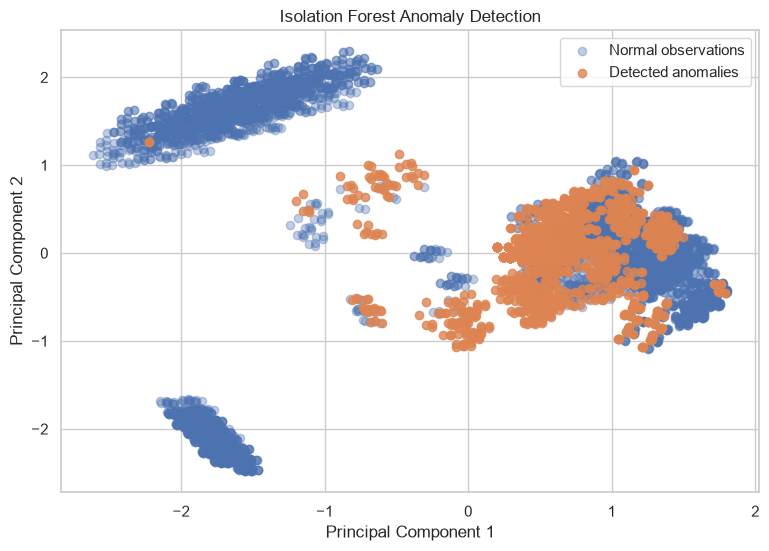

In [50]:

# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# 2. predict -> -1 son anomalias
# 3. Pintarlas sobre la proyeccion PCA

isolation_forest = IsolationForest(
    contamination="auto",
    random_state=RANDOM_STATE
)

anomaly_labels = isolation_forest.fit_predict(X_red)

anomaly_mask = anomaly_labels == -1
n_anomalies = anomaly_mask.sum()

print(f"Detected anomalies: {n_anomalies}")
print(f"Anomaly proportion: {n_anomalies / len(X_red):.2%}")

plt.figure(figsize=(9, 6))

plt.scatter(
    X_visual[~anomaly_mask, 0],
    X_visual[~anomaly_mask, 1],
    alpha=0.35,
    label="Normal observations"
)

plt.scatter(
    X_visual[anomaly_mask, 0],
    X_visual[anomaly_mask, 1],
    alpha=0.8,
    label="Detected anomalies"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()



## Para ir más allá (opcional)

The mandatory analysis is complete. The following extensions could be explored in future iterations:

- **UMAP:** a non-linear dimensionality reduction technique that is often faster than t-SNE and can preserve more global structure.
- **HDBSCAN:** a hierarchical density-based clustering algorithm that can identify clusters with different densities without fixing a single `eps` value.
- **Association Rules:** particularly suitable for categorical One-Hot encoded data. Methods such as Apriori or FP-Growth could reveal interpretable relationships between mushroom characteristics and edibility.

These extensions are intentionally left outside the mandatory workflow to preserve the reproducibility and scope of the current notebook.



## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.